# H2O AutoML 라이브 데모

> RAPIDS LAB 세미나 — Pandas 이후, RAPIDS 이전의 자동화 병렬 ML 프레임워크

---

## 발표 흐름
1. **[Phase 1]** H2O 초기화 + 데이터 로드 + AutoML 학습 시작 (~1분)
2. **[Phase 2]** 학습 대기 중 → README / 슬라이드로 H2O AutoML 설명 (~5분)
3. **[Phase 3]** 학습 완료 후 → 결과 분석 (~4분)

---
## Phase 1: 런타임 시작
### 1-1. H2O 클러스터 초기화

In [1]:
'''
wsl는 켤 태마다 내부적으로 사용할 가상 ip 주소를 매번 새롭게 만듦.
->P1) 파이썬 H2O 클라이언트는 기본적으로 고정된 로컬 주소(127.0.0.1)를 바라보고 있는데
   자바 서버는 매번 바뀌는 가상 IP 주소에서 실행되고, 클라이언트는 이를 찾지 못해 연결 오류가 발생함.
->P2) H2O는 "IP 주소가 127.0.0.1(로컬호스트)이 아니면, 파이썬이 알아서 자바 서버(jar)를 띄워주는 기능을 
   절대 실행하지 않겠다"라고 하드코딩되어 있음.
   
Thus, 아래 코드는 1) 진짜 WSL IP를 찾고, 2) 터미널 명령어를 백그라운드에서 실행한 뒤, 3) H2O에 자동으로 연결
'''
import os
import socket
import subprocess
import time
import h2o

# 1. WSL의 실제 IP(172.x.x.x)를 정확히 가져오는 함수 (127.0.1.1 엉뚱한 주소 방지)
def get_wsl_ip():
    s = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
    try:
        # 외부로 연결하는 시늉만 해서, 시스템이 할당한 진짜 가상 IP를 알아냅니다.
        s.connect(('8.8.8.8', 80))
        IP = s.getsockname()[0]
    except Exception:
        IP = '127.0.0.1'
    finally:
        s.close()
    return IP

wsl_ip = get_wsl_ip()
port = "54321"

# 2. 파이썬 가상환경 내부에 있는 h2o.jar 파일의 절대 경로를 자동으로 찾기
import h2o.backend
jar_path = os.path.join(os.path.dirname(h2o.backend.__file__), "bin", "h2o.jar")

# 3. 서버가 이미 떠있는지 확인하고, 없다면 백그라운드에서 터미널 명령어 실행
try:
    # 이미 켜진 서버가 있는지 확인 (연결 시도)
    h2o.connect(url=f"http://{wsl_ip}:{port}")
    print("H2O 클러스터가 이미 실행 중입니다.")
    
except Exception:
    print(f"[{wsl_ip}] 주소로 H2O 서버를 백그라운드에서 부팅합니다... (약 5초 대기)")
    
    # 터미널에서 'java -jar ...' 치는 것과 완전히 동일한 명령어 구성 
    # -Xmx6G(JVM 힙 메모리)로 6기가 할당, 스레드는 default로 시스템의 모든 코어 사용)
    cmd = ["java", "-Xmx6G", "-jar", jar_path, "-ip", wsl_ip, "-port", port]
    
    # 터미널 창 없이 백그라운드에서 조용히 실행 (로그 숨김)
    subprocess.Popen(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    
    # 자바 서버가 완전히 켜질 때까지 5초 기다려줌
    time.sleep(5)
    
    # 생성된 서버에 파이썬 연결
    h2o.init(url=f"http://{wsl_ip}:{port}")

Connecting to H2O server at http://172.31.67.34:54321 ....... failed.
[172.31.67.34] 주소로 H2O 서버를 백그라운드에서 부팅합니다... (약 5초 대기)
Checking whether there is an H2O instance running at http://172.31.67.34:54321. connected.


H2O_cluster_uptime:,03 secs
H2O_cluster_timezone:,Asia/Seoul
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,11 days
H2O_cluster_name:,sm_ple38
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,6 Gb
H2O_cluster_total_cores:,20
H2O_cluster_allowed_cores:,20
H2O_cluster_status:,"locked, healthy"


In [2]:
h2o.cluster_info()

/tmp/ipykernel_110031/3484606868.py:1: H2ODeprecationWarning: Deprecated, use ``h2o.cluster().show_status()``.
  h2o.cluster_info()


H2O_cluster_uptime:,56 secs
H2O_cluster_timezone:,Asia/Seoul
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,11 days
H2O_cluster_name:,sm_ple38
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,5.976 Gb
H2O_cluster_total_cores:,20
H2O_cluster_allowed_cores:,20
H2O_cluster_status:,"locked, healthy"


### 1-2. 데이터셋 로드

**Credit Card Transactions Dataset**
- 카드 거래 데이터 (정상/사기 라벨 포함)
- 타겟: `is_fraud` (사기 여부, 0/1)
- 약 129만 건 레코드
- 로컬 파일: `datasets/credit_card_transactions.csv`

In [3]:
# 신용카드 거래 데이터셋 로드
# 로컬: datasets/credit_card_transactions.csv
credits = h2o.import_file("../datasets/credit_card_transactions.csv")

print(f"데이터 크기: {credits.shape}")
print(f"컬럼: {credits.columns}")
credits.head(5)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
데이터 크기: (1296675, 24)
컬럼: ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode']


Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,2019-01-01 00:00:18,2.70319e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09 00:00:00,0b242abb623afc578575680df30655b9,1.32538e+09,36.0113,-82.0483,0,28705
1,2019-01-01 00:00:44,6.30423e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.21,149,Special educational needs teacher,1978-06-21 00:00:00,1f76529f8574734946361c461b024d99,1.32538e+09,49.159,-118.186,0,nan
2,2019-01-01 00:00:51,3.88595e+13,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.262,4154,Nature conservation officer,1962-01-19 00:00:00,a1a22d70485983eac12b5b88dad1cf95,1.32538e+09,43.1507,-112.154,0,83236
3,2019-01-01 00:01:16,3.53409e+15,"fraud_Kutch, Hermiston and Farrell",gas_transport,45,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.114,1939,Patent attorney,1967-01-12 00:00:00,6b849c168bdad6f867558c3793159a81,1.32538e+09,47.0343,-112.561,0,nan
4,2019-01-01 00:03:06,3.75534e+14,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28 00:00:00,a41d7549acf90789359a9aa5346dcb46,1.32538e+09,38.675,-78.6325,0,22844


In [4]:
# 데이터 기본 탐색
credits.describe()

Rows:1296675
Cols:24

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
type,int,time,int,enum,enum,real,enum,enum,enum,enum,enum,enum,int,real,real,int,enum,time,string,int,real,real,int,int
mins,0.0,1546300818000.0,60416207185.0,,,1.0,,,,,,,1257.0,20.0271,-165.6723,23.0,,-1425513600000.0,NaN,1325376018.0,19.027785,-166.671242,0.0,1001.0
mean,648337.0,1570106848070.2131,4.1719204207972685e+17,,,70.35103545607036,,,,,,,48800.67109722945,38.537621614899656,-90.22633537864151,88824.44056297839,,118522975017.17853,NaN,1349243636.7261226,38.53733804469972,-90.22646479897276,0.005788651743883394,46825.75415053301
maxs,1296674.0,1592741617000.0,4.992346398065154e+18,,,28948.9,,,,,,,99783.0,66.6933,-67.9503,2906700.0,,1106956800000.0,NaN,1371816817.0,67.510267,-66.950902,1.0,99403.0
sigma,374317.9744882685,12855448282.255966,1.30880644700024e+18,,,160.3160385715277,,,,,,,26893.222476485902,5.075808438803932,13.759076946486315,301956.3606887509,,548805592934.6085,NaN,12841278.423358224,5.10978836967918,13.77109056479242,0.07586268973125163,25834.00115959988
zeros,1,0,0,,,0,,,,,,,0,0,0,0,,0,0,0,0,0,1289169,0
missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,195973
0,0.0,2019-01-01 00:00:18,2703186189652095.0,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654.0,36.0788,-81.1781,3495.0,"Psychologist, counselling",1988-03-09 00:00:00,0b242abb623afc578575680df30655b9,1325376018.0,36.011293,-82.048315,0.0,28705.0
1,1.0,2019-01-01 00:00:44,630423337322.0,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160.0,48.8878,-118.2105,149.0,Special educational needs teacher,1978-06-21 00:00:00,1f76529f8574734946361c461b024d99,1325376044.0,49.159046999999994,-118.186462,0.0,nan
2,2.0,2019-01-01 00:00:51,38859492057661.0,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252.0,42.1808,-112.262,4154.0,Nature conservation officer,1962-01-19 00:00:00,a1a22d70485983eac12b5b88dad1cf95,1325376051.0,43.150704,-112.154481,0.0,83236.0


### 1-3. AutoML 학습 시작

**핵심 포인트**: 이 셀 하나로 6가지 알고리즘 + 하이퍼파라미터 튜닝 + 앙상블이 전부 자동 수행됩니다.

In [5]:
# 예측 변수 / 응답 변수 설정
y = "is_fraud"
x = credits.columns
x.remove(y)

# 누수/식별자 성격 컬럼 제외 (권장)
drop_cols = ["Unnamed: 0", "trans_num"]
x = [c for c in x if c not in drop_cols]

# 응답 변수를 factor로 변환 (이진분류)
credits[y] = credits[y].asfactor()

# Train/Test 분리 (80/20)
train, test = credits.split_frame(ratios=[0.8], seed=42)
print(f"Train: {train.shape}, Test: {test.shape}")
print(f"y: {y}, x 개수: {len(x)}")

Train: (1037442, 24), Test: (259233, 24)
y: is_fraud, x 개수: 21


In [ ]:
%%time

import time
import threading
from tqdm.auto import tqdm
from h2o.automl import H2OAutoML

# ============================================================
# H2O AutoML 실행 — 이것이 전부입니다
# ============================================================
# max_runtime_secs=600 : 10분 동안 가능한 많은 모델 탐색
# seed=42             : 재현성 (단, DeepLearning은 비결정적)
# nfolds=5            : 5-fold cross-validation (기본값)
#
# 내부에서 수행되는 작업:
#   1) XGBoost 사전 정의 모델 3개
#   2) GLM (lambda_search 포함)
#   3) Random Forest (DRF)
#   4) GBM 5개
#   5) Deep Neural Network
#   6) Extremely Randomized Trees (XRT)
#   7) XGBoost/GBM/DNN 랜덤 그리드 서치
#   8) Stacked Ensemble 2종 (Best of Family + All Models)
# ============================================================

# max_runtime_secs = 600
max_runtime_secs = 300 # 5분으로 줄여서 테스트


def ensure_h2o_alive():
    """H2O 연결이 끊겼으면 클러스터를 다시 띄웁니다."""
    try:
        h2o.api("GET /3/Cloud")
        return False
    except Exception:
        print("H2O 연결이 끊겨 클러스터를 재시작합니다...")
        h2o.init(nthreads=-1, max_mem_size="6G")
        return True


restarted = ensure_h2o_alive()
if restarted:
    # 서버 재시작 시 기존 H2OFrame 핸들이 무효가 되므로 데이터/분할을 다시 만듭니다.
    credits = h2o.import_file("../datasets/credit_card_transactions.csv")
    y = "is_fraud"
    x = credits.columns
    x.remove(y)
    drop_cols = ["Unnamed: 0", "trans_num"]
    x = [c for c in x if c not in drop_cols]
    credits[y] = credits[y].asfactor()
    train, test = credits.split_frame(ratios=[0.8], seed=42)

aml = H2OAutoML(
    max_runtime_secs=max_runtime_secs,
    seed=42,
    project_name="credits_automl",
    sort_metric="AUCPR",
    balance_classes=True,
    verbosity="info",
)

# 학습은 별도 스레드에서 실행하고, 메인 스레드에서 경과 시간 진행바를 표시
train_done = False
train_error = None


def _run_train():
    global train_done, train_error
    try:
        aml.train(x=x, y=y, training_frame=train)
    except Exception as e:
        train_error = e
    finally:
        train_done = True


thread = threading.Thread(target=_run_train, daemon=True)
thread.start()

start = time.time()
with tqdm(total=max_runtime_secs, desc="AutoML elapsed (sec)", unit="s") as pbar:
    while not train_done:
        elapsed = int(time.time() - start)
        pbar.n = min(elapsed, max_runtime_secs)
        pbar.refresh()
        time.sleep(1)
    pbar.n = min(int(time.time() - start), max_runtime_secs)
    pbar.refresh()

thread.join()

if train_error is not None:
    raise train_error

print("\n=== AutoML 학습 완료 ===")

AutoML elapsed (sec):   0%|          | 0/600 [00:00<?, ?s/s]

AutoML progress: |
23:58:05.572: Project: credits_automl
23:58:05.573: 5-fold cross-validation will be used.
23:58:05.573: Setting stopping tolerance adaptively based on the training frame: 0.001
23:58:05.573: Build control seed: 42
23:58:05.573: training frame: Frame key: AutoML_1_20260323_235805_training_py_4_sid_8957    cols: 24    rows: 1037442  chunks: 80    size: 134946347  checksum: -8749237035203065570
23:58:05.573: validation frame: NULL
23:58:05.573: leaderboard frame: NULL
23:58:05.573: blending frame: NULL
23:58:05.574: response column: is_fraud
23:58:05.574: fold column: null
23:58:05.574: weights column: null
23:58:05.582: Loading execution steps: [{XGBoost : [def_2 (1g, 10w), def_1 (2g, 10w), def_3 (3g, 10w), grid_1 (4g, 90w), lr_search (6g, 30w)]}, {GLM : [def_1 (1g, 10w)]}, {DRF : [def_1 (2g, 10w), XRT (3g, 10w)]}, {GBM : [def_5 (1g, 10w), def_2 (2g, 10w), def_3 (2g, 10w), def_4 (2g, 10w), def_1 (3g, 10w), grid_1 (4g, 60w), lr_annealing (6g, 10w)]}, {DeepLearning : [de

---

> **여기서 학습이 돌아가는 동안 README.md로 이동하여 H2O AutoML 특징을 설명합니다.**
> 
> (Phase 2: 약 5분 설명)

---

## Phase 3: 결과 분석

### 3-1. 리더보드 확인

AutoML이 학습한 모든 모델의 성능 순위표입니다.

In [10]:
# 리더보드 — 모든 모델의 CV 성능 비교
lb = aml.leaderboard
print(f"총 {lb.nrows}개 모델 학습 완료\n")
lb.head(rows=lb.nrows)

총 16개 모델 학습 완료



model_id,aucpr,auc,logloss,mean_per_class_error,rmse,mse
StackedEnsemble_AllModels_1_AutoML_1_20260323_235805,0.876981,0.996396,0.00672984,0.110229,0.0406649,0.00165364
StackedEnsemble_BestOfFamily_1_AutoML_1_20260323_235805,0.876968,0.996492,0.00673037,0.109901,0.0406664,0.00165375
StackedEnsemble_BestOfFamily_2_AutoML_1_20260323_235805,0.87694,0.99637,0.0067308,0.111543,0.0406663,0.00165374
StackedEnsemble_BestOfFamily_3_AutoML_1_20260323_235805,0.876858,0.996411,0.00673276,0.110392,0.0406736,0.00165434
XGBoost_1_AutoML_1_20260323_235805,0.872551,0.996463,0.0128654,0.111236,0.0578517,0.00334682
GBM_1_AutoML_1_20260323_235805,0.717103,0.954943,0.0270624,0.158781,0.0692025,0.00478898
XGBoost_2_AutoML_1_20260323_235805,0.644896,0.991792,0.0938553,0.11857,0.138723,0.019244
GBM_4_AutoML_1_20260323_235805,0.643097,0.94799,0.0247186,0.181628,0.0739596,0.00547003
GBM_2_AutoML_1_20260323_235805,0.608503,0.95027,0.0232913,0.185808,0.0728713,0.00531022
GBM_3_AutoML_1_20260323_235805,0.60632,0.943339,0.0240057,0.202918,0.0731018,0.00534388


In [11]:
# 확장 리더보드: 학습 시간 + 예측 속도 포함
lb_ext = h2o.automl.get_leaderboard(aml, extra_columns="ALL")
lb_ext.head(rows=lb_ext.nrows)

model_id,aucpr,auc,logloss,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
StackedEnsemble_AllModels_1_AutoML_1_20260323_235805,0.876981,0.996396,0.00672984,0.110229,0.0406649,0.00165364,2875,0.001532,StackedEnsemble
StackedEnsemble_BestOfFamily_1_AutoML_1_20260323_235805,0.876968,0.996492,0.00673037,0.109901,0.0406664,0.00165375,2929,0.001475,StackedEnsemble
StackedEnsemble_BestOfFamily_2_AutoML_1_20260323_235805,0.87694,0.99637,0.0067308,0.111543,0.0406663,0.00165374,2663,0.00148,StackedEnsemble
StackedEnsemble_BestOfFamily_3_AutoML_1_20260323_235805,0.876858,0.996411,0.00673276,0.110392,0.0406736,0.00165434,1963,0.001497,StackedEnsemble
XGBoost_1_AutoML_1_20260323_235805,0.872551,0.996463,0.0128654,0.111236,0.0578517,0.00334682,26991,0.000386,XGBoost
GBM_1_AutoML_1_20260323_235805,0.717103,0.954943,0.0270624,0.158781,0.0692025,0.00478898,33039,0.001191,GBM
XGBoost_2_AutoML_1_20260323_235805,0.644896,0.991792,0.0938553,0.11857,0.138723,0.019244,3323,7.2e-05,XGBoost
GBM_4_AutoML_1_20260323_235805,0.643097,0.94799,0.0247186,0.181628,0.0739596,0.00547003,3044,0.000247,GBM
GBM_2_AutoML_1_20260323_235805,0.608503,0.95027,0.0232913,0.185808,0.0728713,0.00531022,2672,0.000279,GBM
GBM_3_AutoML_1_20260323_235805,0.60632,0.943339,0.0240057,0.202918,0.0731018,0.00534388,3067,0.000285,GBM


### 3-2. 최고 모델 (Leader) 분석

In [12]:
# AutoML이 선택한 최고 모델
leader = aml.leader
print(f"Best Model: {leader.model_id}")
print(f"Algorithm:  {leader.algo}")
print(f"\n--- Model Parameters ---")
leader.params

Best Model: StackedEnsemble_AllModels_1_AutoML_1_20260323_235805
Algorithm:  stackedensemble

--- Model Parameters ---


{'model_id': {'default': None,
  'actual': {'__meta': {'schema_version': 3,
    'schema_name': 'ModelKeyV3',
    'schema_type': 'Key<Model>'},
   'name': 'StackedEnsemble_AllModels_1_AutoML_1_20260323_235805',
   'type': 'Key<Model>',
   'URL': '/3/Models/StackedEnsemble_AllModels_1_AutoML_1_20260323_235805'},
  'input': None},
 'training_frame': {'default': None,
  'actual': {'__meta': {'schema_version': 3,
    'schema_name': 'FrameKeyV3',
    'schema_type': 'Key<Frame>'},
   'name': 'AutoML_1_20260323_235805_training_py_4_sid_8957',
   'type': 'Key<Frame>',
   'URL': '/3/Frames/AutoML_1_20260323_235805_training_py_4_sid_8957'},
  'input': {'__meta': {'schema_version': 3,
    'schema_name': 'FrameKeyV3',
    'schema_type': 'Key<Frame>'},
   'name': 'AutoML_1_20260323_235805_training_py_4_sid_8957',
   'type': 'Key<Frame>',
   'URL': '/3/Frames/AutoML_1_20260323_235805_training_py_4_sid_8957'}},
 'response_column': {'default': None,
  'actual': {'__meta': {'schema_version': 3,
    'sch

In [13]:
# 테스트 데이터에서 성능 평가
perf = leader.model_performance(test)
print(perf)

ModelMetricsBinomialGLM: stackedensemble
** Reported on test data. **

MSE: 0.0015266804623571147
RMSE: 0.039072758571121066
LogLoss: 0.006027704991862967
AUC: 0.9970729582665092
AUCPR: 0.8922589488374494
Gini: 0.9941459165330184
Null degrees of freedom: 259232
Residual degrees of freedom: 259230
Null deviance: 18037.025744454768
Residual deviance: 3125.160096311224
AIC: 3131.160096311224

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.49646367373105693
       0       1     Error    Rate
-----  ------  ----  -------  ----------------
0      257547  226   0.0009   (226.0/257773.0)
1      291     1169  0.1993   (291.0/1460.0)
Total  257838  1395  0.002    (517.0/259233.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.496464     0.818914  162
max f2                       0.25446      0.836743  227
max f0point5          

In [14]:
# AUC 확인
print(f"Test AUC: {perf.auc():.4f}")
print(f"Test Logloss: {perf.logloss():.4f}")

Test AUC: 0.9971
Test Logloss: 0.0060


### 3-3. 알고리즘별 최고 모델 비교

In [15]:
# 알고리즘별 최고 모델 가져오기
algos = ["xgboost", "gbm", "glm", "deeplearning", "drf", "stackedensemble"]

print(f"{'Algorithm':<20} {'Model ID':<55} {'AUC':>8}")
print("-" * 85)

for algo in algos:
    try:
        m = aml.get_best_model(algorithm=algo)
        p = m.model_performance(test)
        print(f"{algo:<20} {m.model_id:<55} {p.auc():>8.4f}")
    except Exception as e:
        print(f"{algo:<20} {'N/A':<55} {str(e)[:8]:>8}")

Algorithm            Model ID                                                     AUC
-------------------------------------------------------------------------------------
xgboost              XGBoost_1_AutoML_1_20260323_235805                        0.9971
gbm                  GBM_1_AutoML_1_20260323_235805                            0.9666
glm                  GLM_1_AutoML_1_20260323_235805                            0.8315
deeplearning         DeepLearning_1_AutoML_1_20260323_235805                   0.9368
drf                  DRF_1_AutoML_1_20260323_235805                            0.8857
stackedensemble      StackedEnsemble_AllModels_1_AutoML_1_20260323_235805      0.9971


### 3-4. Feature Importance

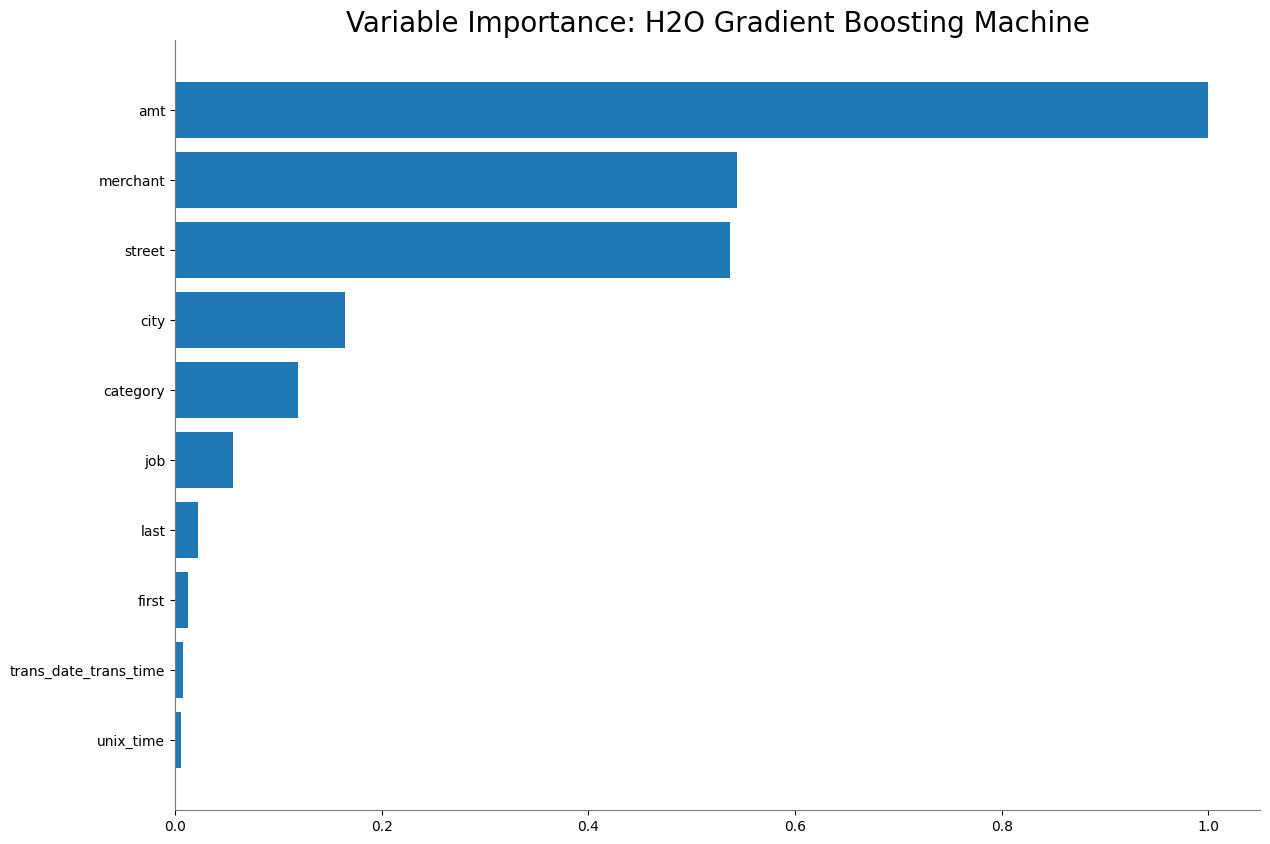

<Figure size 640x480 with 0 Axes>

In [16]:
# 리더 모델의 변수 중요도 (tree 기반 모델인 경우)
# StackedEnsemble인 경우 base learner 중 하나를 사용
best_non_ensemble = aml.get_best_model(algorithm="gbm")
if best_non_ensemble is not None:
    best_non_ensemble.varimp_plot()

### 3-5. 예측 수행

In [17]:
# 테스트 데이터 예측
preds = aml.predict(test)
preds.head(10)

stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


predict,p0,p1
0,0.999681,0.000318512
0,0.999983,1.66132e-05
0,0.999974,2.56659e-05
0,0.999987,1.33409e-05
0,0.999964,3.55501e-05
0,0.999949,5.06837e-05
0,0.999945,5.48155e-05
0,0.999986,1.35616e-05
0,0.99994,6.04763e-05
0,0.999995,5.13435e-06


### 3-6. AutoML 이벤트 로그

학습 과정에서 어떤 일이 일어났는지 확인합니다.

In [18]:
# AutoML 이벤트 로그
aml.event_log.head(rows=30)

timestamp,level,stage,message,name,value
23:58:05.572,INFO,Workflow,Project: credits_automl,,
23:58:05.573,INFO,Validation,5-fold cross-validation will be used.,,
23:58:05.573,INFO,Validation,Setting stopping tolerance adaptively based on the training frame: 0.001,,
23:58:05.573,INFO,Validation,Build control seed: 42,,
23:58:05.573,INFO,DataImport,training frame: Frame key: AutoML_1_20260323_235805_training_py_4_sid_8957 cols: 24 rows: 1037442 chunks: 80 size: 134946347 checksum: -8749237035203065570,,
23:58:05.573,INFO,DataImport,validation frame: NULL,,
23:58:05.573,INFO,DataImport,leaderboard frame: NULL,,
23:58:05.573,INFO,DataImport,blending frame: NULL,,
23:58:05.574,INFO,DataImport,response column: is_fraud,,
23:58:05.574,INFO,DataImport,fold column: null,,


In [19]:
# 학습 정보 요약
print("=== Training Info ===")
for k, v in aml.training_info.items():
    print(f"  {k}: {v}")

=== Training Info ===
  creation_epoch: 1774277886
  start_epoch: 1774277886
  start_XGBoost_def_2: 1774277886
  start_GLM_def_1: 1774278049
  start_GBM_def_5: 1774278174
  start_StackedEnsemble_best_of_family_1: 1774278354
  start_XGBoost_def_1: 1774278356
  start_DRF_def_1: 1774278376
  start_GBM_def_2: 1774278398
  start_GBM_def_3: 1774278417
  start_GBM_def_4: 1774278437
  start_StackedEnsemble_best_of_family_2: 1774278456
  start_StackedEnsemble_all_2: 1774278459
  start_XGBoost_def_3: 1774278462
  start_DRF_XRT: 1774278467
  start_GBM_def_1: 1774278471
  start_DeepLearning_def_1: 1774278476
  start_StackedEnsemble_best_of_family_3: 1774278484
  stop_epoch: 1774278486
  duration_secs: 601


---

## 정리

| 항목 | 결과 |
|------|------|
| 코드 라인 수 | AutoML 실행: **단 6줄** |
| 탐색 알고리즘 | GBM, XGBoost, DRF, GLM, DeepLearning, StackedEnsemble |
| 자동 수행 항목 | 하이퍼파라미터 튜닝, Cross-validation, Early Stopping, 앙상블 |
| 병렬 처리 | JVM 기반 멀티코어 자동 활용 (설정 불필요) |

> **"5분, 6줄의 코드로 수십 개의 모델을 자동 학습하고 최적 앙상블까지 구성"**
> — 이것이 RAPIDS 이전 시대, H2O AutoML이 제시한 답입니다.

In [20]:
# 클러스터 종료
h2o.cluster().shutdown()

H2O session _sid_8957 closed.
